In [1]:
# Importing the necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_raw = pd.read_excel("SAM_TAM_TOM.xlsx", header=None, names=["Metric", "Value", "Type", "Extra"])
metrics = df_raw.set_index("Metric")["Value"]

tam_hh, tam_val = float(metrics["TAM (Households)"]), float(metrics["TAM (Value)"])
sam_hh, sam_val = float(metrics["SAM (Households)"]), float(metrics["SAM (Value)"])
tom_hh, tom_val = float(metrics["TOM (Households)"]), float(metrics["TOM (Value)"])
spend_per_hh = float(metrics["Average Annual Home-Service Spending per Household"])

print(f"TAM: {tam_hh:,.0f} HH | NPR {tam_val/1e9}B")
print(f"SAM: {sam_hh:,.0f} HH | NPR {sam_val/1e9}B")
print(f"TOM: {tom_hh:,.0f} HH | NPR {tom_val/1e9}B")

TAM: 6,666,937 HH | NPR 56.581494286559995B
SAM: 2,520,102 HH | NPR 21.3878048403197B
TOM: 75,603 HH | NPR 0.64163414520959B


### Chart 1 - Market Sizing Overview

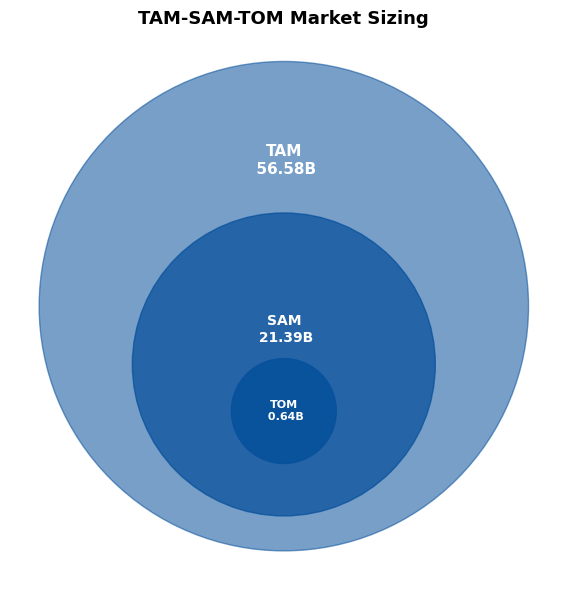

In [3]:
plt.figure(figsize=(6,6))
plt.gca().add_patch(plt.Circle((0.5, 0.5), 0.42, color="#08519c", alpha=0.55))
plt.gca().add_patch(plt.Circle((0.5, 0.40), 0.26, color="#08519c", alpha=0.75))
plt.gca().add_patch(plt.Circle((0.5, 0.32), 0.09, color="#08519c", alpha=0.95))

plt.text(0.5, 0.75, f"TAM\n {tam_val/1e9:.2f}B", ha="center", va="center", fontsize=11, fontweight="bold", color="white")
plt.text(0.5, 0.46, f"SAM\n {sam_val/1e9:.2f}B", ha="center", va="center", fontsize=10, fontweight="bold", color="white")
plt.text(0.5, 0.32, f"TOM\n {tom_val/1e9:.2f}B", ha="center", va="center", fontsize=8, fontweight="bold", color="white")

plt.xlim(0.03, 0.97)
plt.ylim(0.03, 0.97)
plt.gca().set_aspect("equal")
plt.axis("off")
plt.title("TAM-SAM-TOM Market Sizing", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("chart1.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 2 - Percentage of TAM Retained at Each Market Stage

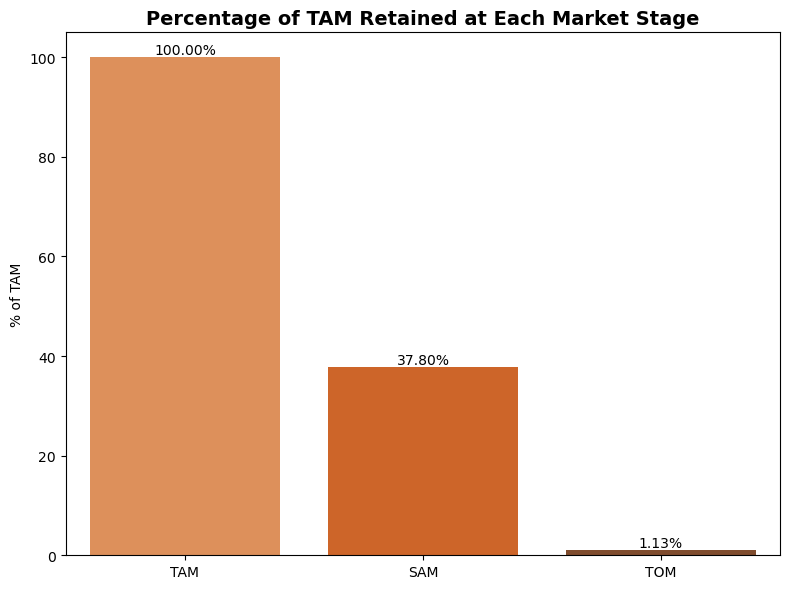

In [4]:
retained = pd.DataFrame({"Stage": ["TAM", "SAM", "TOM"],
                        "Pct": [100, sam_val/tam_val*100, tom_val/tam_val*100]})

plt.figure(figsize=(8,6))
sns.barplot(data=retained, x="Stage", y="Pct", hue="Stage", palette="Oranges_d", legend=False)
plt.title("Percentage of TAM Retained at Each Market Stage", fontsize=14, fontweight="bold")
plt.xlabel(""); plt.ylabel("% of TAM")
for i, v in enumerate(retained["Pct"]):
    plt.text(i, v, f"{v:.2f}%", ha="center", va="bottom", fontsize=10)
plt.tight_layout()
plt.savefig("chart2.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 3 - Sensitivity: TOM Value vs. Market Share Assumption

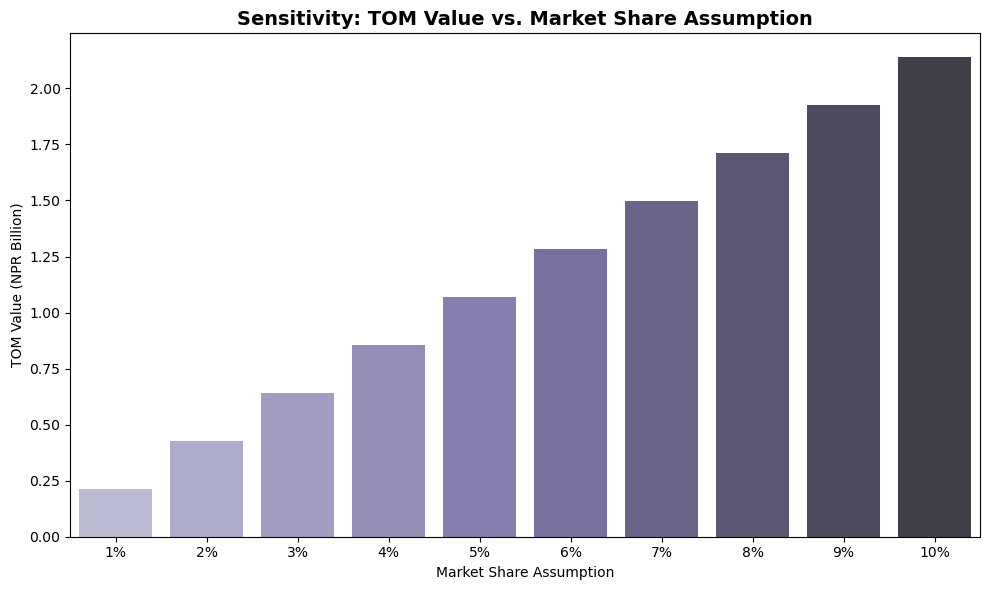

In [5]:
shares = [s/100 for s in range(1, 11)]
sens = pd.DataFrame({"Share": [f"{s}%" for s in range(1, 11)],
                      "TOM_Bn": [sam_hh * s * spend_per_hh / 1e9 for s in shares]})

plt.figure(figsize=(10, 6))
sns.barplot(data=sens, x="Share", y="TOM_Bn", hue="Share", palette="Purples_d", legend=False)
plt.title("Sensitivity: TOM Value vs. Market Share Assumption", fontsize=14, fontweight="bold")
plt.xlabel("Market Share Assumption")
plt.ylabel("TOM Value (NPR Billion)")
plt.tight_layout()
plt.savefig("chart3.png", dpi=150, bbox_inches="tight")
plt.show()

### Chart 4 - Input Data Composition: Official vs. Assumption Input Split

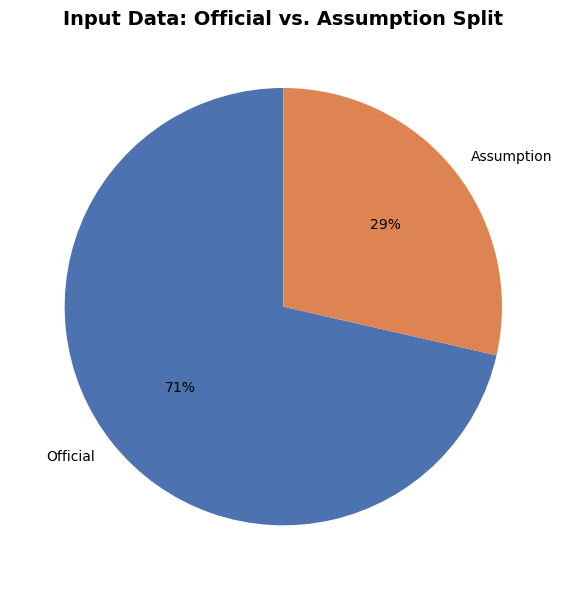

In [6]:
type_counts = df_raw[df_raw["Type"].isin(["Official", "Assumption"])]["Type"].value_counts().reset_index()
type_counts.columns = ["Type", "Count"]

plt.figure(figsize=(6, 6))
plt.pie(type_counts["Count"], labels=type_counts["Type"], autopct="%1.0f%%",
        colors=["#4C72B0", "#DD8452"], startangle=90)
plt.title("Input Data: Official vs. Assumption Split", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("chart4.png", dpi=150, bbox_inches="tight")
plt.show()